# ENet para Segmentação Semântica
Notebook para treinar e testar ENet em PyTorch, compatível com CPU, usando Cityscapes e mesma estrutura do Fast-SCNN.

## 1. Bibliotecas Necessárias

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import numpy as np
import os
import matplotlib.pyplot as plt
import json
from cityscapesscripts.helpers.labels import name2label
from PIL import ImageDraw



## 2. Arquitetura ENet

In [2]:
# Implementação do ENet

class ENet(nn.Module):
    def __init__(self, num_classes=19):
        super(ENet, self).__init__()
        self.initial = nn.Sequential(
            nn.Conv2d(3, 16, 3, padding=1, stride=2),
            nn.BatchNorm2d(16),
            nn.ReLU()
        )
        self.bottleneck = nn.Sequential(
            nn.Conv2d(16, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Conv2d(64, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU()
        )
        self.classifier = nn.Conv2d(64, num_classes, 1)
    def forward(self, x):
        x = self.initial(x)
        x = self.bottleneck(x)
        x = self.classifier(x)
        x = nn.functional.interpolate(x, scale_factor=2, mode='bilinear', align_corners=False)
        return x

## 3. Preparação do Dataset de Segmentação

In [3]:
# Dataset Cityscapes
class CityscapesDataset(Dataset):
    def __init__(self, root, split='train', img_size=(256, 512), max_samples=None):
        self.img_size = img_size
        self.images = []
        self.masks = []
        leftImg_dir = os.path.join(root, 'leftImg8bit', split)
        gtFine_dir = os.path.join(root, 'gtFine', split)
        for city in os.listdir(leftImg_dir):
            img_city_dir = os.path.join(leftImg_dir, city)
            mask_city_dir = os.path.join(gtFine_dir, city)
            for fname in os.listdir(img_city_dir):
                if fname.endswith('_leftImg8bit.png'):
                    img_path = os.path.join(img_city_dir, fname)
                    mask_name = fname.replace('_leftImg8bit.png', '_gtFine_polygons.json')
                    mask_path = os.path.join(mask_city_dir, mask_name)
                    if os.path.exists(mask_path):
                        self.images.append(img_path)
                        self.masks.append(mask_path)
        if max_samples:
            self.images = self.images[:max_samples]
            self.masks = self.masks[:max_samples]
        if len(self.images) == 0:
            raise RuntimeError(f'Nenhuma imagem/máscara encontrada em {leftImg_dir} e {gtFine_dir}')
    def __len__(self):
        return len(self.images)
    def __getitem__(self, idx):
        img = Image.open(self.images[idx]).convert('RGB').resize(self.img_size)
        
        # Rasterizar máscara a partir do JSON
        with open(self.masks[idx], 'r') as f:
            mask_json = json.load(f)
        mask = Image.new('L', (mask_json['imgWidth'], mask_json['imgHeight']), 0)
        draw = ImageDraw.Draw(mask)
        for obj in mask_json['objects']:
            label = obj['label']
            trainId = name2label[label].trainId if label in name2label else 255
            if trainId == 255:
                continue
            polygon = [(x, y) for [x, y] in obj['polygon']]
            draw.polygon(polygon, fill=trainId)
        mask = mask.resize(self.img_size, Image.NEAREST)
        img = np.array(img, dtype=np.float32) / 255.0
        mask = np.array(mask, dtype=np.int64)
        img_tensor = torch.from_numpy(img).permute(2, 0, 1).float()
        mask_tensor = torch.from_numpy(mask).long()
        return img_tensor, mask_tensor

## 4. Modelo ENet

In [4]:
# modelo ENet para GPU se disponível
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = ENet(num_classes=19).to(device)
if device.type == 'cuda':
    print('Modelo ENet inicializado para GPU:', torch.cuda.get_device_name(0))
else:
    print('Modelo ENet inicializado para CPU.')

Modelo ENet inicializado para GPU: NVIDIA GeForce GTX 1660 SUPER


## 5. Loop de Treinamento

In [5]:
# Inicialização do dataset e dataloader
dataset_root = 'd:/Documentos/Git/edge-segmentation-lab/city'
train_dataset = CityscapesDataset(dataset_root, split='train', img_size=(256, 512), max_samples=2300)
train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True)

criterion = nn.CrossEntropyLoss(ignore_index=255)
optimizer = optim.Adam(model.parameters(), lr=1e-3)

num_epochs = 10
print(f'Treinando por {num_epochs} épocas com {len(train_dataset)} imagens...')
for epoch in range(num_epochs):
    model.train()
    train_loss = 0.0
    for imgs, masks in train_loader:
        imgs, masks = imgs.to(device), masks.to(device)
        optimizer.zero_grad()
        outputs = model(imgs)
        if masks.dim() == 4 and masks.shape[1] == 1:
            masks = masks.squeeze(1)
        loss = criterion(outputs, masks)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
    avg_loss = train_loss / len(train_loader)
    print(f'Epoch {epoch+1}/{num_epochs} | Loss: {avg_loss:.4f}')

Treinando por 10 épocas com 2300 imagens...
Epoch 1/10 | Loss: 1.1036
Epoch 2/10 | Loss: 0.9414
Epoch 3/10 | Loss: 0.9122
Epoch 4/10 | Loss: 0.8848
Epoch 5/10 | Loss: 0.8735
Epoch 6/10 | Loss: 0.8565
Epoch 7/10 | Loss: 0.8421
Epoch 8/10 | Loss: 0.8389
Epoch 9/10 | Loss: 0.8246
Epoch 10/10 | Loss: 0.8205


## Modelo Treinado

In [6]:
torch.save(model.state_dict(), 'enet_cpu_best.pth')
print('Modelo salvo em enet_cpu_best.pth')

Modelo salvo em enet_cpu_best.pth


## Visualização de Resultados

Avaliando 5 imagens de Munique...


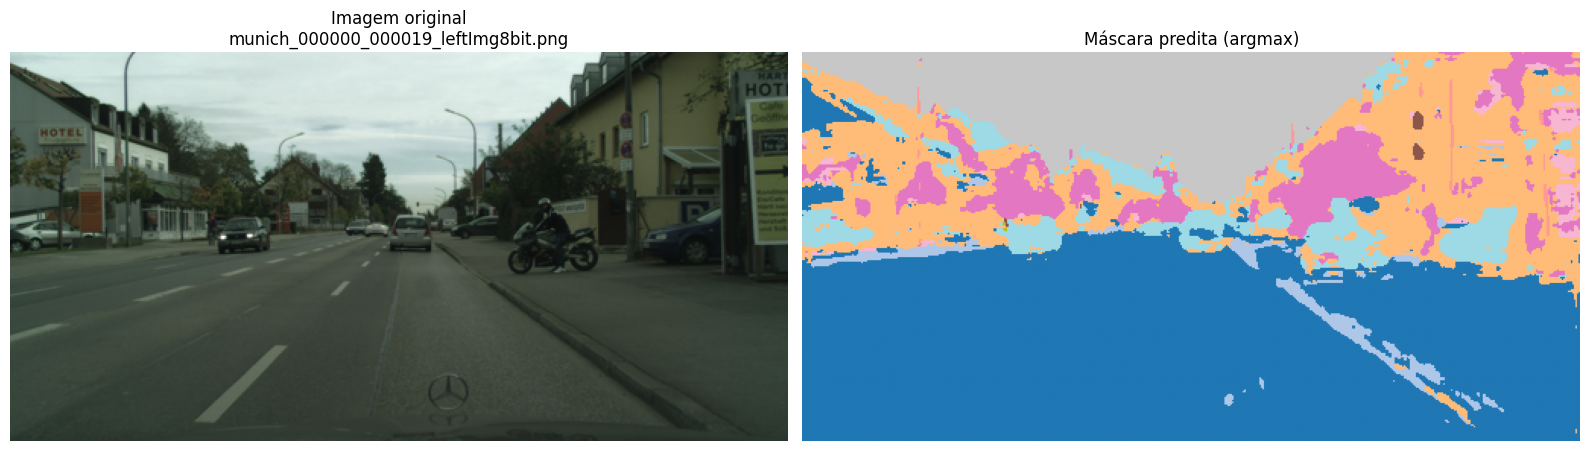

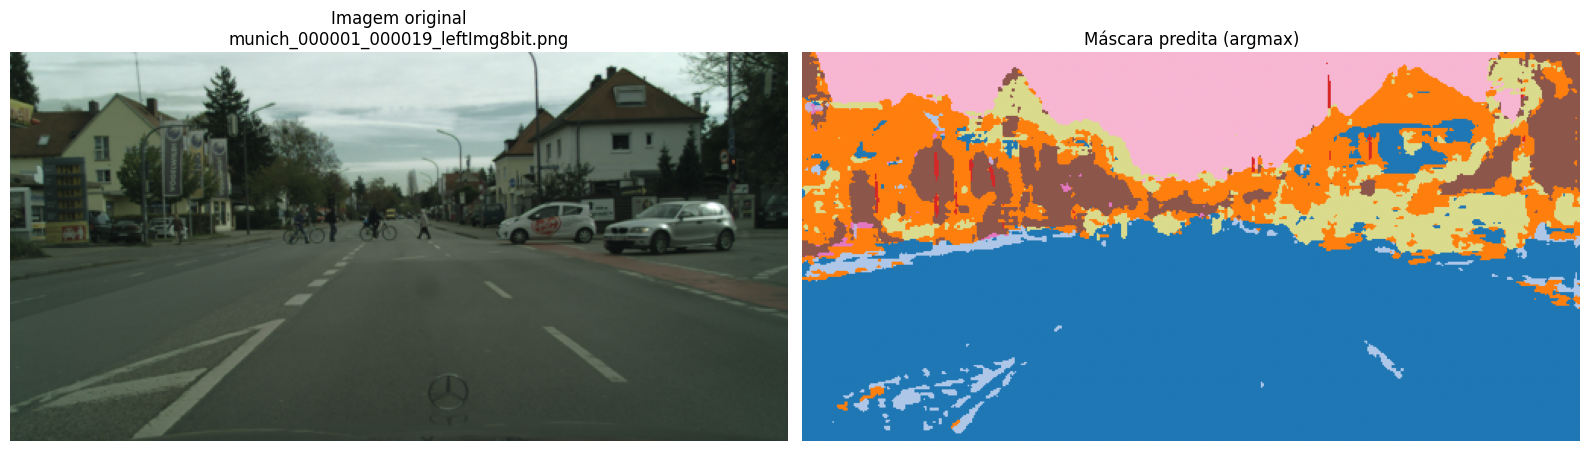

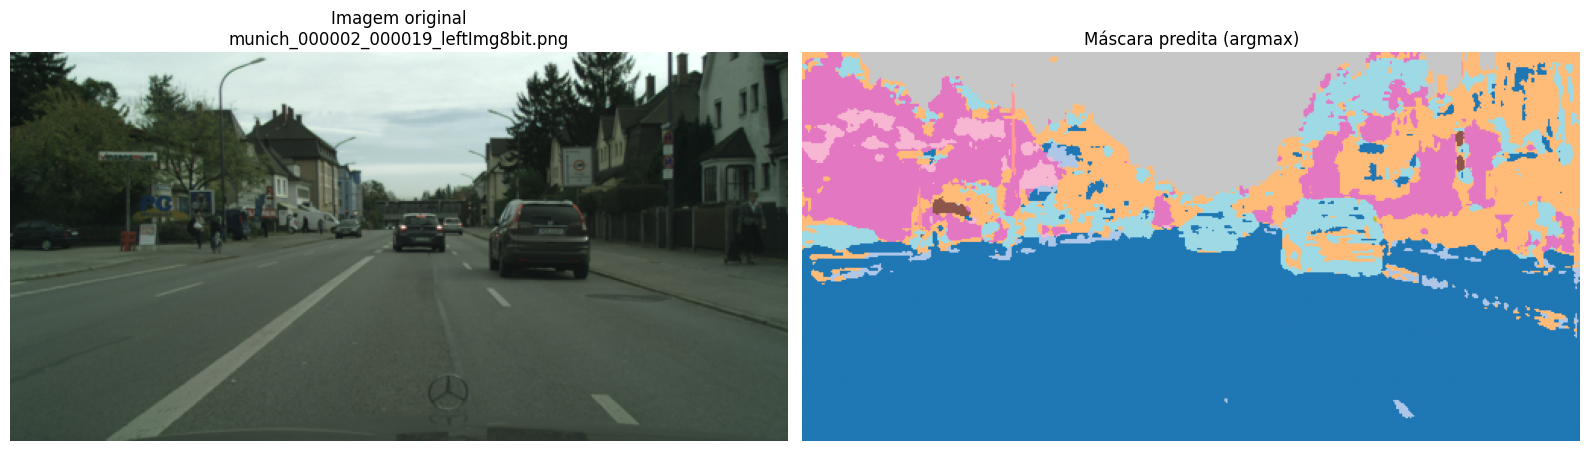

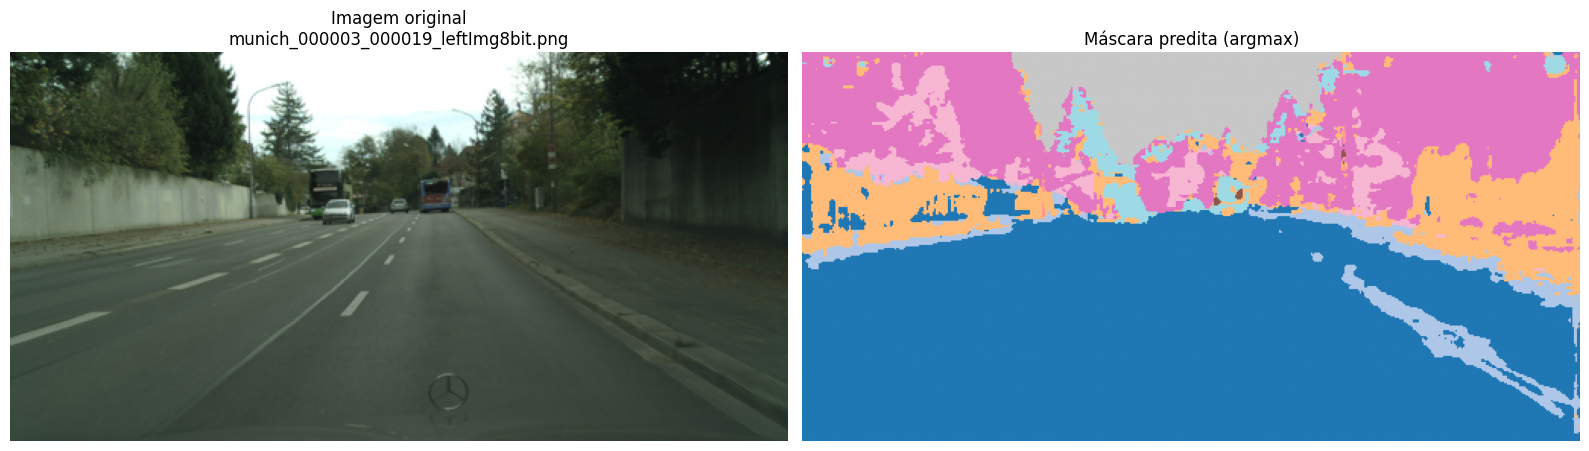

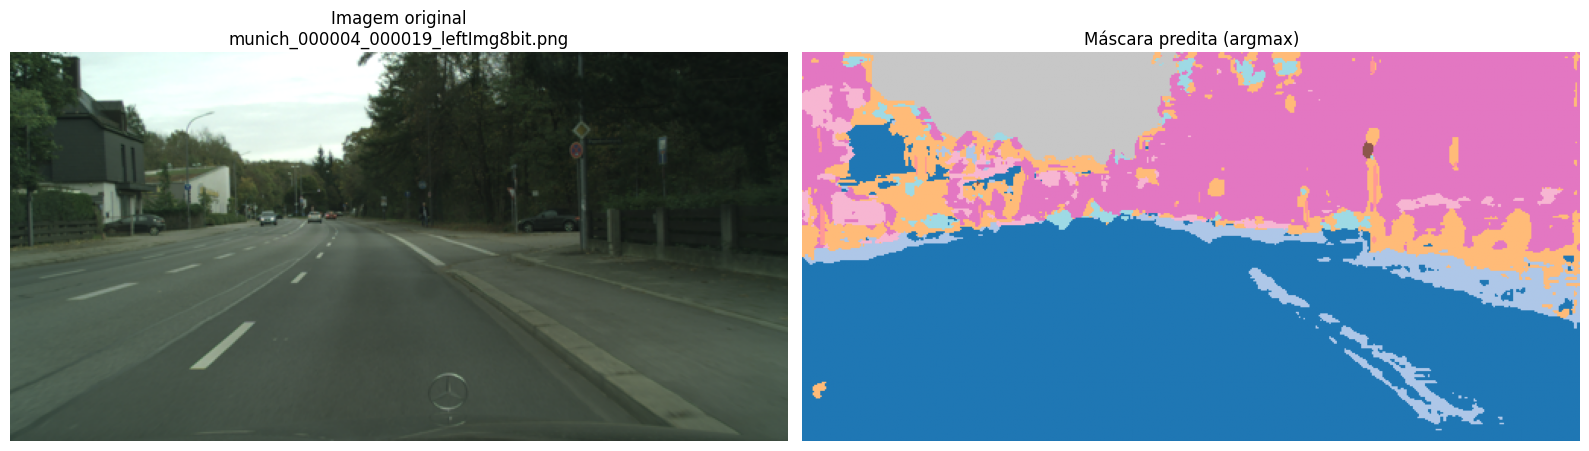

In [7]:
# Avaliação em imagens de Munique -> sem máscara ground truth
import glob
munich_dir = r'D:\Documentos\Git\edge-segmentation-lab\city\leftImg8bit\test\munich'
munich_imgs = sorted(glob.glob(os.path.join(munich_dir, '*_leftImg8bit.png')))[:5]
print(f'Avaliando {len(munich_imgs)} imagens de Munique...')
for img_path in munich_imgs:
    img = Image.open(img_path).convert('RGB').resize((512, 256))
    img_np = np.array(img, dtype=np.float32) / 255.0
    img_tensor = torch.from_numpy(img_np).permute(2, 0, 1).unsqueeze(0).float().to(device)
    model.eval()
    with torch.no_grad():
        output = model(img_tensor)
        pred_mask = torch.argmax(output, dim=1).squeeze().cpu().numpy()
    plt.figure(figsize=(16,6))
    plt.subplot(1,2,1)
    plt.title(f'Imagem original\n{os.path.basename(img_path)}')
    plt.imshow(img)
    plt.axis('off')
    plt.subplot(1,2,2)
    plt.title('Máscara predita (argmax)')
    plt.imshow(pred_mask, cmap='tab20')
    plt.axis('off')
    plt.tight_layout()
    plt.show()